________________________

## M10-Evaluation

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

M10_TAG = "M10_inputzscore_resdilated_emb64_d124_train400k"

HISTORY_PATH = DATA_ROOT / "results" / DATASET_ID / (
    f"{DATASET_ID}_SimpleCNN_ResidualDilated_"
    f"{M10_TAG}_MSELoss_seed123_history.npz"
)

PRED_PATH = DATA_ROOT / "results" / DATASET_ID / (
    "m10_inputzscore_500k_cal_test_predictions_embeddings.npz"
)

OUTPUT_DIR = DATA_ROOT / "results" / DATASET_ID / "m10_inputzscore_500k_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("HISTORY_PATH:", HISTORY_PATH, HISTORY_PATH.exists())
print("PRED_PATH:", PRED_PATH, PRED_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

HISTORY_PATH: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_history.npz True
PRED_PATH: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz True
OUTPUT_DIR: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_evaluation


In [3]:
hist = np.load(HISTORY_PATH)

print(hist.files)

for k in hist.files:
    print(k, hist[k].shape, hist[k].dtype)

train_loss = hist["train_loss"]
val_loss = hist["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)
best_epoch = int(np.argmin(val_loss) + 1)
best_val = float(np.min(val_loss))

print("best_epoch:", best_epoch)
print("best_val:", best_val)

['train_loss', 'val_loss', 'train_time', 'val_time', 'epoch_time']
train_loss (94,) float64
val_loss (94,) float64
train_time (94,) float64
val_time (94,) float64
epoch_time (94,) float64
best_epoch: 69
best_val: 0.11357601894140243


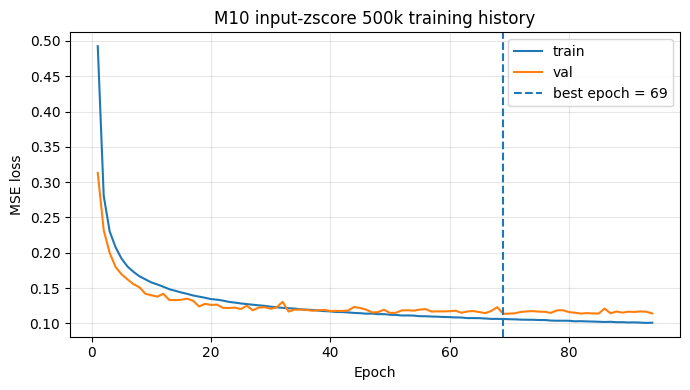

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_evaluation/m10_500k_train_val_loss.png


In [4]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("M10 input-zscore 500k training history")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = OUTPUT_DIR / "m10_500k_train_val_loss.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

### Load preds cal/test

In [8]:
if not PRED_PATH.exists():
    raise FileNotFoundError(
        f"Prediction file not found yet:\n{PRED_PATH}\n\n"
        "Run scripts/predict_cnn_hdf5.py after training finishes."
    )

pred_data = np.load(PRED_PATH, allow_pickle=True)

print("Files:")
for k in pred_data.files:
    arr = pred_data[k]
    print(f"{k:25s}", arr.shape, arr.dtype)

Files:
y_mean                    (3,) float32
y_std                     (3,) float32
label_names               (3,) <U10
checkpoint_file           () <U196
dataset_path              () <U86
split_path                () <U142
label_stats_path          () <U158
model_config              () object
input_normalization       () object
available_splits          (2,) <U4
pred_cal                  (30000, 3) float32
emb_cal                   (30000, 64) float32
y_cal                     (30000, 3) float32
idx_cal                   (30000,) int64
pred_test                 (30000, 3) float32
emb_test                  (30000, 64) float32
y_test                    (30000, 3) float32
idx_test                  (30000,) int64


In [9]:
pred_cal_std = pred_data["pred_cal"].astype(np.float32)
y_cal_std = pred_data["y_cal"].astype(np.float32)
emb_cal = pred_data["emb_cal"].astype(np.float32)

pred_test_std = pred_data["pred_test"].astype(np.float32)
y_test_std = pred_data["y_test"].astype(np.float32)
emb_test = pred_data["emb_test"].astype(np.float32)

y_mean = pred_data["y_mean"].astype(np.float32)
y_std = pred_data["y_std"].astype(np.float32)
label_names = [str(x) for x in pred_data["label_names"].tolist()]

input_normalization = pred_data["input_normalization"].item()

print("label_names:", label_names)
print("input_normalization:", input_normalization)

assert input_normalization["enabled"] is True
assert input_normalization["mode"] == "per_sample_per_detector_zscore"

print("pred_cal_std:", pred_cal_std.shape)
print("pred_test_std:", pred_test_std.shape)
print("emb_cal:", emb_cal.shape)
print("emb_test:", emb_test.shape)

label_names: ['chirp_mass', 'total_mass', 'chi_eff']
input_normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}
pred_cal_std: (30000, 3)
pred_test_std: (30000, 3)
emb_cal: (30000, 64)
emb_test: (30000, 64)


In [10]:
def inverse_label_standardization(y_std_values, y_mean, y_std):
    return y_std_values * y_std[None, :] + y_mean[None, :]

pred_cal_phys = inverse_label_standardization(pred_cal_std, y_mean, y_std)
y_cal_phys = inverse_label_standardization(y_cal_std, y_mean, y_std)

pred_test_phys = inverse_label_standardization(pred_test_std, y_mean, y_std)
y_test_phys = inverse_label_standardization(y_test_std, y_mean, y_std)

In [11]:
def regression_metrics(y_true, y_pred, label_names):
    rows = []

    for j, name in enumerate(label_names):
        err = y_pred[:, j] - y_true[:, j]

        mse = np.mean(err**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(err))
        bias = np.mean(err)

        ss_res = np.sum(err**2)
        ss_tot = np.sum((y_true[:, j] - np.mean(y_true[:, j]))**2)
        r2 = 1.0 - ss_res / ss_tot

        rows.append({
            "label": name,
            "rmse": float(rmse),
            "mae": float(mae),
            "bias": float(bias),
            "r2": float(r2),
        })

    return pd.DataFrame(rows)

metrics_std_df = regression_metrics(y_test_std, pred_test_std, label_names)
metrics_phys_df = regression_metrics(y_test_phys, pred_test_phys, label_names)

display(metrics_std_df)
display(metrics_phys_df)

metrics_std_df.to_csv(OUTPUT_DIR / "m10_500k_test_metrics_std.csv", index=False)
metrics_phys_df.to_csv(OUTPUT_DIR / "m10_500k_test_metrics_phys.csv", index=False)

,label,rmse,mae,bias,r2
0,chirp_mass,0.300274,0.207245,0.013218,0.910353
1,total_mass,0.270409,0.201655,0.031125,0.927000
2,chi_eff,0.423588,0.315976,0.053638,0.820138


,label,rmse,mae,bias,r2
0,chirp_mass,4.949937,3.416382,0.217900,0.910353
1,total_mass,9.369734,6.987367,1.078494,0.927000
2,chi_eff,0.186741,0.139300,0.023647,0.820138
